# Rename Files

In [ ]:
from pathlib import Path

def rename_files_by_prefix_rules(folder, dry_run=True):
    """
    Rename files in a folder using these rules:
      4.9_ball_*.csv -> 1-*.csv
      4.9_rota_*.csv -> 2-*.csv
      4.9_be_*.csv   -> 3-*.csv
      4.9_h_*.csv    -> 4-*.csv

    Example:
      4.9_ball_3.csv -> 1-3.csv
      4.9_rota_7.csv -> 2-7.csv
    """
    folder = Path(folder)

    prefix_map = {
        "4.9_ball_": "1-",
        "4.9_rota_": "2-",
        "4.9_be_":   "3-",
        "4.9_h_":    "4-",
    }

    renamed = []

    for old_path in sorted(folder.glob("*.csv")):
        old_name = old_path.name
        old_stem = old_path.stem

        matched = False
        for old_prefix, new_prefix in prefix_map.items():
            if old_stem.startswith(old_prefix):
                suffix = old_stem[len(old_prefix):]
                new_name = f"{new_prefix}{suffix}.csv"
                new_path = old_path.with_name(new_name)

                if new_path.exists() and new_path != old_path:
                    print(f"Skip (target exists): {old_name} -> {new_name}")
                    matched = True
                    break

                print(f"{'Would rename' if dry_run else 'Renaming'}: {old_name} -> {new_name}")
                renamed.append((old_path, new_path))

                if not dry_run:
                    old_path.rename(new_path)

                matched = True
                break

        if not matched:
            print(f"Skip (no rule matched): {old_name}")

    print(f"\nTotal renamed/matched: {len(renamed)}")
    return renamed

In [ ]:
rename_files_by_prefix_rules(folder = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_eit_adc", dry_run=True)

Skip (no rule matched): 1-1.csv
Skip (no rule matched): 1-10.csv
Skip (no rule matched): 1-2.csv
Skip (no rule matched): 1-3.csv
Skip (no rule matched): 1-4.csv
Skip (no rule matched): 1-5.csv
Skip (no rule matched): 1-6.csv
Skip (no rule matched): 1-7.csv
Skip (no rule matched): 1-8.csv
Skip (no rule matched): 1-9.csv
Skip (no rule matched): 1-t.csv
Skip (no rule matched): 2-1.csv
Skip (no rule matched): 2-10.csv
Skip (no rule matched): 2-2.csv
Skip (no rule matched): 2-3.csv
Skip (no rule matched): 2-4.csv
Skip (no rule matched): 2-5.csv
Skip (no rule matched): 2-6.csv
Skip (no rule matched): 2-7.csv
Skip (no rule matched): 2-8.csv
Skip (no rule matched): 2-9.csv
Skip (no rule matched): 3-1.csv
Skip (no rule matched): 3-10.csv
Skip (no rule matched): 3-2.csv
Skip (no rule matched): 3-3.csv
Skip (no rule matched): 3-4.csv
Skip (no rule matched): 3-5.csv
Skip (no rule matched): 3-6.csv
Skip (no rule matched): 3-7.csv
Skip (no rule matched): 3-8.csv
Skip (no rule matched): 3-9.csv
Skip 

[]

# Processing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_cap_vs_time(csv_path, t_start=None, t_end=None, per_cap_idx=True):
    df = pd.read_csv(csv_path)

    # Parse + clean
    df["timestamp_dt"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp_dt"]).copy()

    if "source" in df.columns:
        df = df[df["source"].astype(str).str.lower() == "cap"].copy()

    df["cap0"] = pd.to_numeric(df["cap0"], errors="coerce")
    df["cap_idx"] = pd.to_numeric(df.get("cap_idx"), errors="coerce")
    df = df.dropna(subset=["cap0"]).sort_values("timestamp_dt").copy()

    # Optional time window
    if t_start is not None and t_end is not None:
        t_start = pd.to_datetime(t_start)
        t_end   = pd.to_datetime(t_end)
        df = df[(df["timestamp_dt"] >= t_start) & (df["timestamp_dt"] <= t_end)].copy()

    if len(df) == 0:
        print("No CAP rows to plot.")
        return

    plt.figure(figsize=(12, 4))

    if per_cap_idx and "cap_idx" in df.columns and df["cap_idx"].notna().any():
        for idx, sub in df.groupby("cap_idx"):
            plt.plot(sub["timestamp_dt"], sub["cap0"], linewidth=1, label=f"cap_idx={int(idx)}")
        plt.legend(ncol=4, fontsize=8)
    else:
        plt.plot(df["timestamp_dt"], df["cap0"], linewidth=1)

    plt.grid(True)
    plt.xlabel("Time")
    plt.ylabel("cap0")
    plt.title("CAP vs time")
    plt.tight_layout()
    plt.show()


In [2]:
import numpy as np

def plot_cap_vs_index(csv_path, t_start=None, t_end=None, per_cap_idx=True):
    df = pd.read_csv(csv_path)

    # Parse + clean
    df["timestamp_dt"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp_dt"]).copy()

    if "source" in df.columns:
        df = df[df["source"].astype(str).str.lower() == "cap"].copy()

    df["cap0"] = pd.to_numeric(df["cap0"], errors="coerce")
    df["cap_idx"] = pd.to_numeric(df.get("cap_idx"), errors="coerce")
    df = df.dropna(subset=["cap0"]).sort_values("timestamp_dt").copy()

    # Optional time window
    if t_start is not None and t_end is not None:
        t_start = pd.to_datetime(t_start)
        t_end   = pd.to_datetime(t_end)
        df = df[(df["timestamp_dt"] >= t_start) & (df["timestamp_dt"] <= t_end)].copy()

    if len(df) == 0:
        print("No CAP rows to plot.")
        return

    # Re-index to continuous integer index
    df = df.reset_index(drop=True)
    df["x"] = np.arange(len(df))

    plt.figure(figsize=(12, 4))

    if per_cap_idx and "cap_idx" in df.columns and df["cap_idx"].notna().any():
        for idx, sub in df.groupby("cap_idx"):
            plt.plot(sub["x"], sub["cap0"], linewidth=1, label=f"cap_idx={int(idx)}")
        plt.legend(ncol=4, fontsize=8)
    else:
        plt.plot(df["x"], df["cap0"], linewidth=1)

    plt.grid(True)
    plt.xlabel("Sample index (continuous)")
    plt.ylabel("cap0")
    plt.title("CAP vs continuous index (no time gaps)")
    plt.tight_layout()
    plt.show()


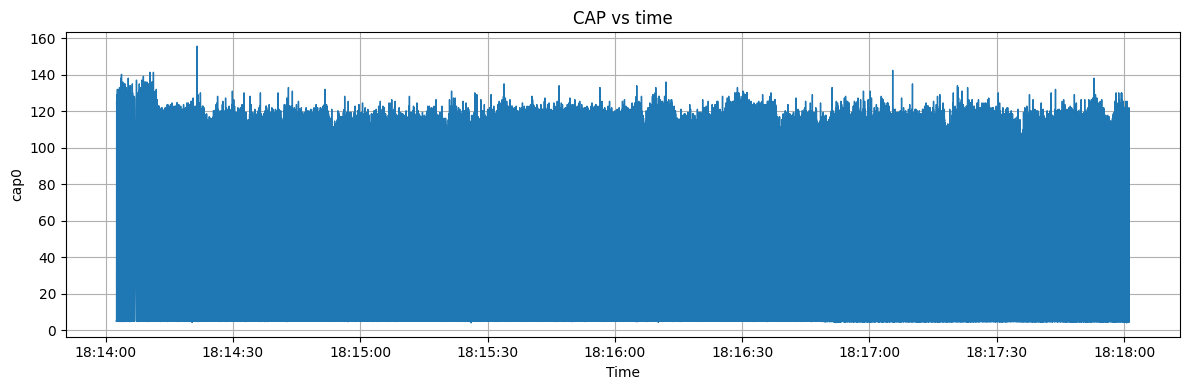

In [3]:
plot_cap_vs_time("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_cap_joint/1-1.csv", per_cap_idx=False)

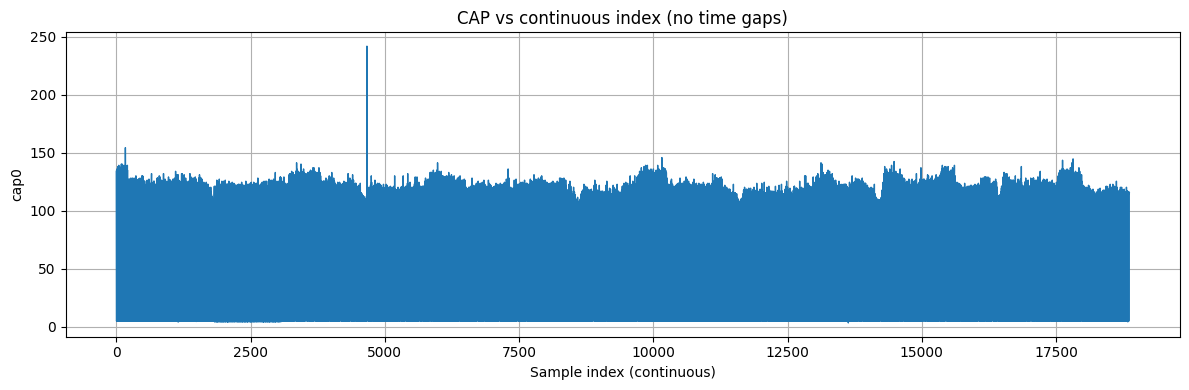

In [16]:
plot_cap_vs_index("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_cap_joint/1-2.csv", per_cap_idx=False)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def remove_cap_off_and_reindex(cap_clean, thr=10,
                              time_col="timestamp", src_col="source",
                              cap_col="cap0", idx_col="cap_idx"):
    df = cap_clean.copy()

    # keep CAP rows (if source exists)
    if src_col in df.columns:
        df = df[df[src_col].astype(str).str.lower() == "cap"].copy()

    # parse time + numeric cap
    df["timestamp_dt"] = pd.to_datetime(df[time_col], errors="coerce")
    df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce")
    if idx_col in df.columns:
        df[idx_col] = pd.to_numeric(df[idx_col], errors="coerce")

    df = df.dropna(subset=["timestamp_dt", cap_col]).sort_values("timestamp_dt")

    # remove CAP-off rows
    df = df[df[cap_col] >= thr].copy()

    # make continuous index (no gaps)
    df = df.reset_index(drop=True)
    df["x"] = np.arange(len(df))

    return df

def plot_cap_continuous(df_no_off, per_cap_idx=True, subplots=False,
                        cap_col="cap0", idx_col="cap_idx"):
    if len(df_no_off) == 0:
        print("No rows left after filtering. Try a lower threshold.")
        return

    # --- Plot vs continuous index (no gaps) ---
    if per_cap_idx and idx_col in df_no_off.columns and df_no_off[idx_col].notna().any():
        groups = sorted(df_no_off[idx_col].dropna().unique())

        if subplots:
            fig, axes = plt.subplots(len(groups), 1, figsize=(12, 2.0 * len(groups)), sharex=True)
            if len(groups) == 1:
                axes = [axes]
            for ax, g in zip(axes, groups):
                sub = df_no_off[df_no_off[idx_col] == g]
                ax.plot(sub["x"], sub[cap_col], linewidth=1)
                ax.set_ylabel(f"idx {int(g)}")
                ax.grid(True)
            axes[-1].set_xlabel("Sample index (continuous, CAP<10 removed)")
            fig.suptitle("CAP (>=10) vs continuous index", y=0.995)
            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(12, 4))
            for g in groups:
                sub = df_no_off[df_no_off[idx_col] == g]
                plt.plot(sub["x"], sub[cap_col], linewidth=1, label=f"cap_idx={int(g)}")
            plt.grid(True)
            plt.xlabel("Sample index (continuous, CAP<10 removed)")
            plt.ylabel(cap_col)
            plt.title("CAP (>=10) vs continuous index")
            plt.legend(ncol=4, fontsize=8)
            plt.tight_layout()
            plt.show()
    else:
        plt.figure(figsize=(12, 4))
        plt.plot(df_no_off["x"], df_no_off[cap_col], linewidth=1)
        plt.grid(True)
        plt.xlabel("Sample index (continuous, CAP<10 removed)")
        plt.ylabel(cap_col)
        plt.title("CAP (>=10) vs continuous index")
        plt.tight_layout()
        plt.show()


In [4]:
import pandas as pd
import numpy as np

def remove_cap_artifacts_by_burst_edges(
    df,
    time_col="timestamp",
    src_col="source",
    src_value="cap",
    cap_cols=("cap0",),
    idx_col="cap_idx",
    gap_ms=200,      # threshold to detect a new CAP burst (tune this)
    drop_head=0,     # drop first N rows in each burst
    drop_tail=0,     # drop last N rows in each burst
):
    """
    Returns:
      cap_raw: filtered CAP rows (sorted)
      cap_clean: CAP rows after dropping burst edges
      bad: the dropped rows (for debugging)
    """

    x = df.copy()

    # ---- filter CAP rows if 'source' exists ----
    if src_col in x.columns:
        x = x[x[src_col].astype(str).str.lower() == str(src_value).lower()].copy()

    # ---- parse timestamps ----
    if time_col not in x.columns:
        raise KeyError(f"'{time_col}' not found. Columns are: {list(df.columns)}")

    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[time_col]).copy()

    # ---- numeric ----
    for c in cap_cols:
        if c in x.columns:
            x[c] = pd.to_numeric(x[c], errors="coerce")
    if idx_col in x.columns:
        x[idx_col] = pd.to_numeric(x[idx_col], errors="coerce")

    # Keep rows where cap is valid
    keep_cols = [c for c in cap_cols if c in x.columns]
    x = x.dropna(subset=keep_cols).copy()

    # ---- sort ----
    sort_cols = [time_col] + ([idx_col] if idx_col in x.columns else [])
    x = x.sort_values(sort_cols).reset_index(drop=True)

    # ---- detect burst starts ----
    dt_ms = x[time_col].diff().dt.total_seconds().fillna(0) * 1000.0

    new_burst = dt_ms > gap_ms

    # Also treat cap_idx reset as a new burst (optional but often useful)
    if idx_col in x.columns and x[idx_col].notna().any():
        idx_reset = x[idx_col].diff().fillna(0) < 0
        new_burst = new_burst | idx_reset

    burst_id = new_burst.cumsum()
    x["burst_id"] = burst_id

    # ---- mark head/tail rows to drop per burst ----
    drop_mask = np.zeros(len(x), dtype=bool)

    if drop_head > 0:
        head_mask = x.groupby("burst_id").cumcount() < drop_head
        drop_mask |= head_mask.to_numpy()

    if drop_tail > 0:
        # distance from end inside each burst
        from_end = x.groupby("burst_id").cumcount(ascending=False)
        tail_mask = from_end < drop_tail
        drop_mask |= tail_mask.to_numpy()

    bad = x[drop_mask].copy()
    cap_clean = x[~drop_mask].copy()

    # cleanup helper column
    cap_raw = x.drop(columns=["burst_id"])
    cap_clean = cap_clean.drop(columns=["burst_id"])
    bad = bad.drop(columns=["burst_id"])

    return cap_raw, cap_clean, bad


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def remove_cap_off_and_reindex(cap_clean, thr=10, thr2=1600,
                              time_col="timestamp", src_col="source",
                              cap_col="cap0", idx_col="cap_idx"):
    df = cap_clean.copy()

    # keep CAP rows (if source exists)
    if src_col in df.columns:
        df = df[df[src_col].astype(str).str.lower() == "cap"].copy()

    # parse time + numeric cap
    df["timestamp_dt"] = pd.to_datetime(df[time_col], errors="coerce")
    df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce")
    if idx_col in df.columns:
        df[idx_col] = pd.to_numeric(df[idx_col], errors="coerce")

    df = df.dropna(subset=["timestamp_dt", cap_col]).sort_values("timestamp_dt")

    # remove CAP-off rows
    df = df[df[cap_col] >= thr].copy()
    df = df[df[cap_col] <= thr2].copy()

    # make continuous index (no gaps)
    df = df.reset_index(drop=True)
    df["x"] = np.arange(len(df))

    return df

def plot_cap_continuous(df_no_off, per_cap_idx=False, subplots=False,
                        cap_col="cap0", idx_col="cap_idx"):
    if len(df_no_off) == 0:
        print("No rows left after filtering. Try a lower threshold.")
        return

    # --- Plot vs continuous index (no gaps) ---
    if per_cap_idx and idx_col in df_no_off.columns and df_no_off[idx_col].notna().any():
        groups = sorted(df_no_off[idx_col].dropna().unique())

        if subplots:
            fig, axes = plt.subplots(len(groups), 1, figsize=(12, 2.0 * len(groups)), sharex=True)
            if len(groups) == 1:
                axes = [axes]
            for ax, g in zip(axes, groups):
                sub = df_no_off[df_no_off[idx_col] == g]
                ax.plot(sub["x"], sub[cap_col], linewidth=1)
                ax.set_ylabel(f"idx {int(g)}")
                # ax.grid(True)
                # ax.ylim(80,180)
            axes[-1].set_xlabel("Sample index (continuous, CAP<10 removed)")
            fig.suptitle("CAP (>=10) vs continuous index", y=0.995)
            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(12, 4))
            for g in groups:
                sub = df_no_off[df_no_off[idx_col] == g]
                plt.plot(sub["x"], sub[cap_col], linewidth=1, label=f"cap_idx={int(g)}")
            # plt.grid(True)
            plt.ylim(80,180)
            plt.xlabel("Sample index (continuous, CAP<10 removed)")
            plt.ylabel(cap_col)
            plt.title("CAP (>=10) vs continuous index")
            plt.legend(ncol=4, fontsize=8)
            plt.tight_layout()
            plt.show()
    else:
        plt.figure(figsize=(12, 4))
        plt.plot(df_no_off["x"], df_no_off[cap_col], linewidth=1)
        # plt.grid(True)
        # plt.ylim(80,180)
        plt.xlabel("Sample index (continuous, CAP<10 removed)")
        plt.ylabel(cap_col)
        plt.title("CAP (>=10) vs continuous index")
        plt.tight_layout()
        plt.show()


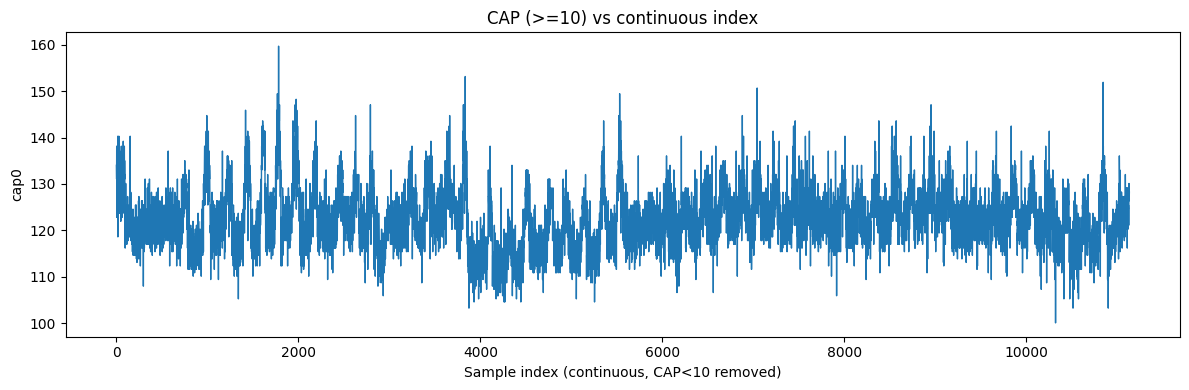

In [6]:
from pathlib import Path

file_path = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_cap_joint/4-1.csv"

df = pd.read_csv(file_path)

cap_raw, cap_clean, bad = remove_cap_artifacts_by_burst_edges(
    df,
    time_col="timestamp",
    src_col="source",
    src_value="cap",
    cap_cols=("cap0",),
    idx_col="cap_idx",
    gap_ms=100,     # tune: try 50 / 100 / 200 / 500 depending on your logging rate
    drop_head=0,    # set to what you want (e.g., 10)
    drop_tail=0,
)

cap_no_off = remove_cap_off_and_reindex(cap_raw, thr=100, thr2=400)

# Option A: overlay lines by cap_idx
plot_cap_continuous(cap_no_off)


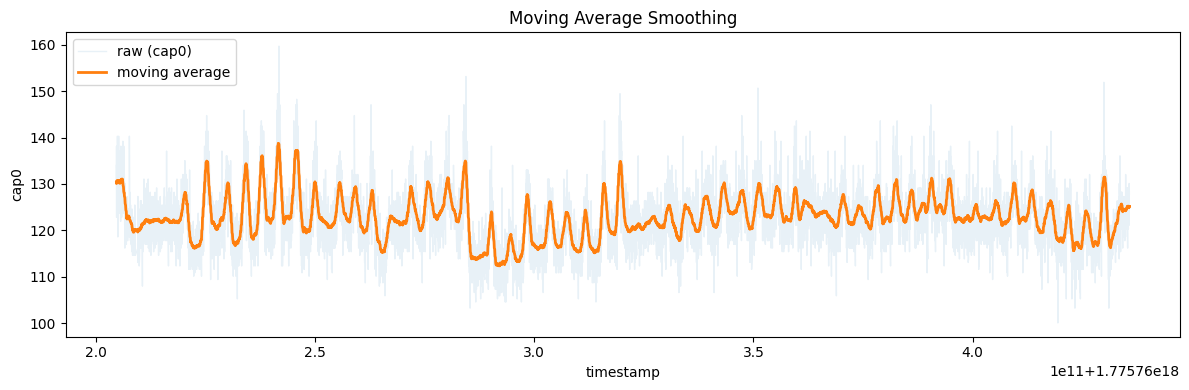

In [7]:
import pandas as pd
import numpy as np

# Make sure it's time-sorted
cap_ma = cap_no_off.copy()
cap_ma["timestamp"] = pd.to_numeric(cap_ma["timestamp"], errors="coerce")
cap_ma["cap0"] = pd.to_numeric(cap_ma["cap0"], errors="coerce")
cap_ma = cap_ma.dropna(subset=["timestamp", "cap0"]).sort_values("timestamp").reset_index(drop=True)

# --- choose ONE of these window definitions ---

# (1) Window by number of samples (good if sampling rate is stable)
win_samples = 50
cap_ma["cap0_ma"] = cap_ma["cap0"].rolling(window=win_samples, center=True, min_periods=1).mean()

# (2) Window by time (better if sampling rate varies)
# cap_ma["dt_s"] = cap_ma["timestamp"].diff().median() / 1000.0   # if timestamp is in ms
# fs_est = 1.0 / cap_ma["dt_s"]
# win_seconds = 0.2
# win_samples = max(1, int(round(win_seconds * fs_est)))
# cap_ma["cap0_ma"] = cap_ma["cap0"].rolling(window=win_samples, center=True, min_periods=1).mean()

# Now cap_ma has a smoothed column "cap0_ma"

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(cap_ma["timestamp"], cap_ma["cap0"], label="raw (cap0)", linewidth=1, alpha=0.1)
plt.plot(cap_ma["timestamp"], cap_ma["cap0_ma"], label="moving average", linewidth=2)
plt.xlabel("timestamp")
plt.ylabel("cap0")
plt.title("Moving Average Smoothing")
plt.legend()
# plt.ylim(80,180)
plt.tight_layout()
plt.show()



In [157]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---- paths ----
in_path = Path(file_path)  # original mixed cap+angle file
out_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/processed_cap")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{in_path.stem}_cap_with_angle.csv"

# ---- read original to get ANGLE ----
df = pd.read_csv(in_path)
df.columns = [str(c).strip().lower() for c in df.columns]

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["type"] = df["type"].astype(str).str.lower()

# pick the angle column robustly
angle_candidates = ["angle_deg", "angle", "deg", "angledegree"]
angle_col = next((c for c in angle_candidates if c in df.columns), None)
if angle_col is None:
    raise KeyError(f"No angle column found. Available columns: {list(df.columns)}")

df_angle = df.loc[df["type"].eq("angle"), ["timestamp", angle_col]].copy()
df_angle[angle_col] = pd.to_numeric(df_angle[angle_col], errors="coerce")
df_angle = df_angle.dropna(subset=["timestamp", angle_col]).sort_values("timestamp")

if len(df_angle) == 0:
    raise ValueError("No valid angle rows found (type=='angle' and numeric angle).")

# rename to avoid collisions after merge
df_angle = df_angle.rename(columns={angle_col: "angle_deg_meas"})

# ---- prepare processed CAP (cap_ma) ----
cap_proc = cap_ma.copy()
cap_proc.columns = [str(c).strip().lower() for c in cap_proc.columns]

if "timestamp" not in cap_proc.columns:
    raise ValueError(
        "cap_ma has no 'timestamp' column, so we can't time-align angle.\n"
        "If cap_ma has cap_idx, I can give you a cap_idx-based merge."
    )

cap_proc["timestamp"] = pd.to_datetime(cap_proc["timestamp"], errors="coerce")
cap_proc = cap_proc.dropna(subset=["timestamp"]).sort_values("timestamp")

# choose the processed cap value column
if "cap0_processed" in cap_proc.columns:
    pass
elif "cap0" in cap_proc.columns:
    cap_proc = cap_proc.rename(columns={"cap0": "cap0_processed"})
elif "cap" in cap_proc.columns:
    cap_proc = cap_proc.rename(columns={"cap": "cap0_processed"})
else:
    num_cols = cap_proc.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        raise ValueError("cap_ma has no numeric column for processed cap.")
    cap_proc = cap_proc.rename(columns={num_cols[0]: "cap0_processed"})

# ---- merge angle onto processed cap by time (most recent angle) ----
out = pd.merge_asof(
    cap_proc.sort_values("timestamp"),
    df_angle.sort_values("timestamp"),
    on="timestamp",
    direction="backward",
    allow_exact_matches=True
)

# fill any leading gaps if cap starts before first angle
out["angle_deg_meas"] = out["angle_deg_meas"].ffill().bfill()

# (optional) final column name you want
out = out.rename(columns={"angle_deg_meas": "angle_deg"})

# ---- save ----
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Rows saved (processed cap samples): {len(out)}")
print("Output columns:", list(out.columns))


Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/processed_cap/4-10_cap_with_angle.csv
Rows saved (processed cap samples): 6936
Output columns: ['timestamp', 'type', 'angle_deg', 'cap0_processed', 'cap_idx', 'raw_line', 'timestamp_dt', 'x', 'cap0_ma', 'angle_deg']


Inferred timestamp unit: ns
Downsampled rows: 2093


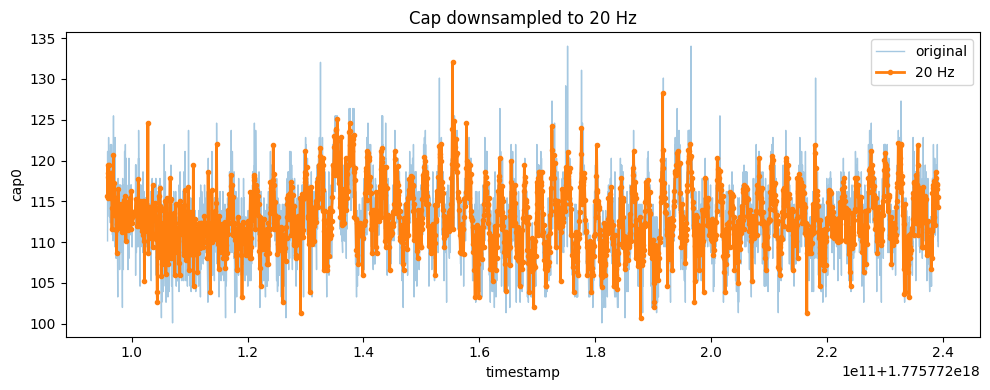

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# def infer_epoch_unit(ts_numeric: np.ndarray) -> str:
#     """
#     Infer epoch unit from magnitude:
#       s  ~ 1e9
#       ms ~ 1e12
#       us ~ 1e15
#       ns ~ 1e18
#     """
#     m = np.nanmedian(ts_numeric)
#     if m > 1e17:
#         return "ns"
#     elif m > 1e14:
#         return "us"
#     elif m > 1e11:
#         return "ms"
#     else:
#         return "s"

# # ---------- Prep ----------
# cap_20 = cap_ma.copy()
# cap_20["timestamp"] = pd.to_numeric(cap_20["timestamp"], errors="coerce")
# cap_20["cap0"] = pd.to_numeric(cap_20["cap0"], errors="coerce")
# cap_20 = cap_20.dropna(subset=["timestamp", "cap0"]).sort_values("timestamp").reset_index(drop=True)

# # ---------- Infer unit + downsample to 20 Hz ----------
# unit = infer_epoch_unit(cap_20["timestamp"].to_numpy())
# cap_20["t"] = pd.to_datetime(cap_20["timestamp"].astype("int64"), unit=unit, errors="coerce")
# cap_20 = cap_20.dropna(subset=["t"]).set_index("t")

# cap_20hz = (
#     cap_20.resample("50ms")
#     .mean(numeric_only=True)
#     .dropna(subset=["cap0"])
#     .reset_index()
# )

# # Restore numeric timestamp in SAME unit as input
# if unit == "ns":
#     cap_20hz["timestamp"] = cap_20hz["t"].astype("int64")
# elif unit == "us":
#     cap_20hz["timestamp"] = cap_20hz["t"].astype("int64") // 1_000
# elif unit == "ms":
#     cap_20hz["timestamp"] = cap_20hz["t"].astype("int64") // 1_000_000
# else:  # seconds
#     cap_20hz["timestamp"] = cap_20hz["t"].astype("int64") / 1e9

# cap_20hz = cap_20hz.drop(columns=["t"])

# print("Inferred timestamp unit:", unit)
# print("Downsampled rows:", len(cap_20hz))

# # ---------- Plot ----------
# cap_plot = cap_no_off.copy()
# cap_plot["timestamp"] = pd.to_numeric(cap_plot["timestamp"], errors="coerce")
# cap_plot["cap0"] = pd.to_numeric(cap_plot["cap0"], errors="coerce")
# cap_plot = cap_plot.dropna(subset=["timestamp", "cap0"]).sort_values("timestamp")

# plt.figure(figsize=(10, 4))
# plt.plot(cap_plot["timestamp"], cap_plot["cap0"], alpha=0.4, linewidth=1, label="original")
# plt.plot(cap_20hz["timestamp"], cap_20hz["cap0"], marker="o", markersize=3, linewidth=2, label="20 Hz")
# plt.xlabel("timestamp")
# plt.ylabel("cap0")
# plt.title("Cap downsampled to 20 Hz")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
# from datetime import datetime

# # --- after you computed cap_clean and cap_no_off ---
# n_before = len(cap_clean)     # before removing cap_off (after burst-edge cleaning)
# n_after  = len(cap_no_off)    # after removing cap_off

# in_path = Path(file_path)
# out_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/clean_cap")
# out_dir.mkdir(parents=True, exist_ok=True)

# # ---- save filtered data ----
# cols_to_drop = [c for c in ["timestamp_dt", "x"] if c in cap_no_off.columns]
# cap_no_off_save = cap_no_off.drop(columns=cols_to_drop)

# out_csv = out_dir / f"{in_path.stem}_CAP_clean.csv"
# cap_no_off_save.to_csv(out_csv, index=False)
# print("Saved:", out_csv)

# # ---- log threshold to txt ----
# log_path = out_dir / "cap_threshold_log.txt"

# # write header once if file doesn't exist
# if not log_path.exists():
#     log_path.write_text("datetime\tfile\tthr\trows_before\trows_after\n")

# with open(log_path, "a") as f:
#     f.write(f"{datetime.now().isoformat(timespec='seconds')}\t{in_path.name}\t{thr}\t{n_before}\t{n_after}\n")

# print("Logged:", log_path)

Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/clean_cap/4-12_CAP_clean.csv
Logged: /Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/clean_cap/cap_threshold_log.txt


# Method 2

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_relay_events(relay_csv,
                      time_candidates=("timestamp", "timestamp_la"),
                      state_candidates=("relay_state", "relay_on")):
    r = pd.read_csv(relay_csv)

    time_col = next((c for c in time_candidates if c in r.columns), None)
    if time_col is None:
        raise KeyError(f"No time column found in relay file. Columns: {list(r.columns)}")

    state_col = next((c for c in state_candidates if c in r.columns), None)
    if state_col is None:
        raise KeyError(f"No state column found in relay file. Columns: {list(r.columns)}")

    r["t"] = pd.to_datetime(r[time_col], errors="coerce")
    r[state_col] = pd.to_numeric(r[state_col], errors="coerce")
    r = r.dropna(subset=["t", state_col]).sort_values("t").copy()

    # keep only state changes
    r["state"] = r[state_col].round().astype(int)
    changed = r["state"].ne(r["state"].shift(1))
    r = r[changed].reset_index(drop=True)

    return r[["t", "state"]]


def intervals_for_1_to_0(relay_events, pad_after_ms=0, pad_before_ms=0):
    """
    For each 1->0 at time t_i, build interval:
      [t_i + pad_after_ms, t_{i+1} - pad_before_ms)
    """
    pad_after  = pd.Timedelta(milliseconds=pad_after_ms)
    pad_before = pd.Timedelta(milliseconds=pad_before_ms)

    t = relay_events["t"].to_numpy()
    s = relay_events["state"].to_numpy()

    intervals = []
    for i in range(1, len(relay_events)):
        if s[i-1] == 1 and s[i] == 0:
            start = t[i] + pad_after
            end = (t[i+1] - pad_before) if (i+1 < len(relay_events)) else None

            # skip impossible/empty intervals
            if end is not None and end <= start:
                continue

            intervals.append((start, end))
    return intervals

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_relay_events(relay_csv,
                      time_candidates=("timestamp", "timestamp_la"),
                      state_candidates=("relay_state", "relay_on")):
    r = pd.read_csv(relay_csv)

    time_col = next((c for c in time_candidates if c in r.columns), None)
    if time_col is None:
        raise KeyError(f"No time column found in relay file. Columns: {list(r.columns)}")

    state_col = next((c for c in state_candidates if c in r.columns), None)
    if state_col is None:
        raise KeyError(f"No state column found in relay file. Columns: {list(r.columns)}")

    r["t"] = pd.to_datetime(r[time_col], errors="coerce")
    r[state_col] = pd.to_numeric(r[state_col], errors="coerce")
    r = r.dropna(subset=["t", state_col]).sort_values("t").copy()

    # keep only state changes
    r["state"] = r[state_col].round().astype(int)
    changed = r["state"].ne(r["state"].shift(1))
    r = r[changed].reset_index(drop=True)

    return r[["t", "state"]]


def intervals_for_1_to_0(relay_events, pad_after_ms=0, pad_before_ms=0):
    """
    For each 1->0 at time t_i, build interval:
      [t_i + pad_after_ms, t_{i+1} - pad_before_ms)
    """
    pad_after  = pd.Timedelta(milliseconds=pad_after_ms)
    pad_before = pd.Timedelta(milliseconds=pad_before_ms)

    t = relay_events["t"].to_numpy()
    s = relay_events["state"].to_numpy()

    intervals = []
    for i in range(1, len(relay_events)):
        if s[i-1] == 1 and s[i] == 0:
            start = t[i] + pad_after
            end = (t[i+1] - pad_before) if (i+1 < len(relay_events)) else None

            # skip impossible/empty intervals
            if end is not None and end <= start:
                continue

            intervals.append((start, end))
    return intervals


In [11]:
def keep_cap_by_relay_intervals_and_reindex(
    cap_df_in,
    relay_intervals,
    time_col="timestamp",
    src_col="source",
    src_value="cap",
    cap_col="cap0",
    idx_col="cap_idx",
    thr=None,   # set to a number (e.g., 10) if you also want CAP>=thr; otherwise None
):
    df = cap_df_in.copy()

    # keep CAP rows (if source exists)
    if src_col in df.columns:
        df = df[df[src_col].astype(str).str.lower().str.strip() == str(src_value).lower()].copy()

    # parse time + numeric cap
    df["timestamp_dt"] = pd.to_datetime(df[time_col], errors="coerce")
    df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce")
    if idx_col in df.columns:
        df[idx_col] = pd.to_numeric(df[idx_col], errors="coerce")

    df = df.dropna(subset=["timestamp_dt", cap_col]).sort_values("timestamp_dt").copy()

    # optional CAP threshold (if you still want to remove small values)
    if thr is not None:
        df = df[df[cap_col] >= thr].copy()

    # keep only rows that fall inside relay 1->0 intervals
    if len(relay_intervals) == 0:
        # nothing to keep
        df = df.iloc[0:0].copy()
        df["x"] = np.array([], dtype=int)
        return df

    tvals = df["timestamp_dt"].to_numpy()
    mask = np.zeros(len(df), dtype=bool)

    for start, end in relay_intervals:
        if end is None:
            mask |= (tvals >= start)
        else:
            mask |= (tvals >= start) & (tvals < end)

    df = df[mask].copy()

    # make continuous index (no gaps)
    df = df.reset_index(drop=True)
    df["x"] = np.arange(len(df))

    return df

def cap_keep_by_intervals_and_reindex(
    cap_df_in,
    relay_intervals,
    time_col="timestamp",
    src_col="source",
    src_value="cap",
    cap_col="cap0",
    idx_col="cap_idx",
    drop_head=0,   # drop N samples after 1->0 within EACH interval
    drop_tail=0,   # drop N samples before next change within EACH interval
):
    df = cap_df_in.copy()

    # keep CAP rows (if source exists)
    if src_col in df.columns:
        df = df[df[src_col].astype(str).str.lower().str.strip() == str(src_value).lower()].copy()

    # parse time + numeric
    df["timestamp_dt"] = pd.to_datetime(df[time_col], errors="coerce")
    df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce")
    if idx_col in df.columns:
        df[idx_col] = pd.to_numeric(df[idx_col], errors="coerce")

    df = df.dropna(subset=["timestamp_dt", cap_col]).sort_values("timestamp_dt").copy()

    if len(relay_intervals) == 0:
        out = df.iloc[0:0].copy()
        out["x"] = np.array([], dtype=int)
        return out

    # collect segments
    pieces = []
    tvals = df["timestamp_dt"].to_numpy()

    for seg_id, (start, end) in enumerate(relay_intervals):
        if end is None:
            m = (tvals >= start)
        else:
            m = (tvals >= start) & (tvals < end)

        seg = df[m].copy()
        if len(seg) == 0:
            continue

        # drop N samples at beginning/end of each segment
        if drop_head > 0:
            seg = seg.iloc[drop_head:].copy()
        if drop_tail > 0 and len(seg) > 0:
            seg = seg.iloc[:-drop_tail].copy()

        if len(seg) == 0:
            continue

        seg["seg"] = seg_id
        pieces.append(seg)

    if not pieces:
        out = df.iloc[0:0].copy()
        out["x"] = np.array([], dtype=int)
        return out

    out = pd.concat(pieces, ignore_index=True)
    out["x"] = np.arange(len(out))  # continuous index (no gaps)
    return out


Intervals: 368
Kept CAP rows: 636


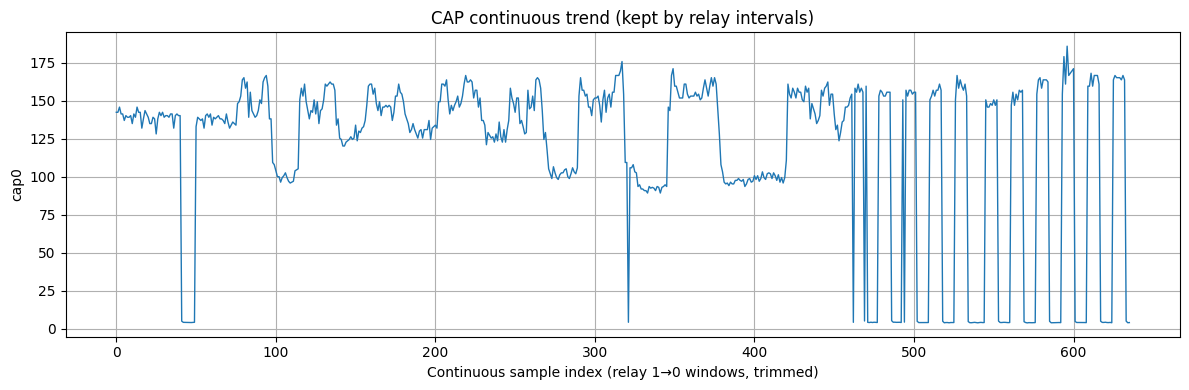

In [37]:
def plot_cap_continuous(df_no_off, cap_col="cap0"):
    if len(df_no_off) == 0:
        print("No rows left after filtering.")
        return
    plt.figure(figsize=(12,4))
    plt.plot(df_no_off["x"], df_no_off[cap_col], linewidth=1)
    plt.grid(True)
    plt.xlabel("Continuous sample index (relay 1→0 windows, trimmed)")
    plt.ylabel(cap_col)
    plt.title("CAP continuous trend (kept by relay intervals)")
    plt.tight_layout()
    plt.show()

relay_csv = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/0_relay_switching/4-1_LAtime.csv"
cap_csv   = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_collection/raw_cap/4-1.csv"

relay_events = load_relay_events(relay_csv)

# Time-based guard around switching boundaries (optional)
intervals = intervals_for_1_to_0(
    relay_events,
    pad_after_ms=5,    # skip first 5 ms after 1->0
    pad_before_ms=5,   # skip last 5 ms before next change
)
print("Intervals:", len(intervals))

cap_df = pd.read_csv(cap_csv)

cap_keep = cap_keep_by_intervals_and_reindex(
    cap_df,
    intervals,
    time_col="timestamp",
    drop_head=5,   # also drop 3 samples at start of each interval
    drop_tail=1,   # and 3 samples at end
)

print("Kept CAP rows:", len(cap_keep))
plot_cap_continuous(cap_keep)
